# Comparative Analysis — Beginner vs Expert, Normal vs Constrained Decoding

This notebook compares the four result CSV files generated by the pipeline:

- `outputs/results_beginner.csv`
- `outputs/results_beginner_CD.csv`
- `outputs/results_expert.csv`
- `outputs/results_expert_CD.csv`

It mirrors the Stage 4 analysis notebook, but focuses on cross-file comparisons, paired deltas, and the biggest row-level changes.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

Using 10 BEGINNER rows for λ sweep calibration.
[Loader] Loading LLM 'Qwen/Qwen2.5-1.5B-Instruct' …


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[Loader] LLM ready.



The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



λ sweep summary


,lambda,mean_fre,mean_dale_chall,pct_fre_ge_55
0,0.01,36.229895,12.384339,10.0
1,0.05,36.440309,12.344875,10.0
2,1.00,38.757925,12.007809,0.0
3,3.00,47.626008,11.019379,30.0
4,5.00,61.480332,10.081509,70.0
5,7.50,65.668815,11.206404,70.0


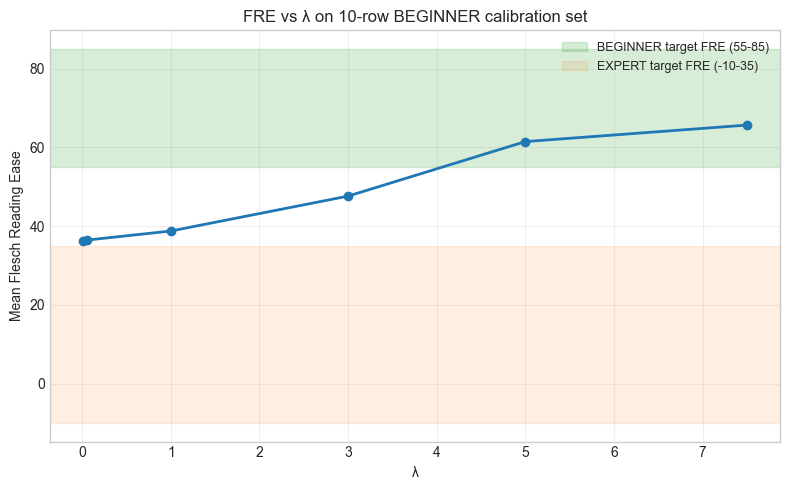

Recommended operating λ (lowest mean FRE >= 55): 5.0


In [2]:
# ── λ SWEEP — run this first to confirm operating parameters ──────────────
from constrained_decoding import LAMBDA_MAP as CD_LAMBDA_MAP, ReadabilityBeamGenerator
from model_loaders import load_llm
from pipeline_helpers import SYSTEM_PROMPT
import config
import textstat

sweep_df = pd.read_csv(Path("outputs/results_beginner.csv")).head(10).copy()
print(f"Using {len(sweep_df)} BEGINNER rows for λ sweep calibration.")

tokenizer, llm_model = load_llm()
generator = ReadabilityBeamGenerator(model=llm_model, tokenizer=tokenizer)

original_beginner_lambda = float(config.LAMBDA_MAP.get("BEGINNER", 0.0))
sweep_rows = []

try:
    for lambda_value in config.LAMBDA_SWEEP_VALUES:
        config.LAMBDA_MAP["BEGINNER"] = float(lambda_value)
        CD_LAMBDA_MAP["BEGINNER"] = float(lambda_value)

        generated_texts = []
        for _, row in sweep_df.iterrows():
            predicted_class = str(row.get("predicted_class", "Unknown"))
            input_text = str(row.get("text", ""))
            task_prompt = (
                "### INPUT\n"
                f"Predicted class: {predicted_class}\n"
                "User category: BEGINNER\n"
                f"Abstract: {input_text}\n\n"
                "### TASK\n"
                "Explain in simple language why this abstract maps to the predicted class. "
                "Use short sentences, avoid jargon, and stay faithful to the abstract.\n\n"
                "### EXPLANATION:"
            )
            generated = generator.generate(
                system_prompt=SYSTEM_PROMPT,
                task_prompt=task_prompt,
                user_category="BEGINNER",
            )
            generated_texts.append(generated)

        fre_scores = [textstat.flesch_reading_ease(t) for t in generated_texts]
        dale_scores = [textstat.dale_chall_readability_score(t) for t in generated_texts]
        pct_fre_ge_55 = 100.0 * sum(score >= 55 for score in fre_scores) / max(len(fre_scores), 1)

        sweep_rows.append(
            {
                "lambda": float(lambda_value),
                "mean_fre": float(pd.Series(fre_scores).mean()),
                "mean_dale_chall": float(pd.Series(dale_scores).mean()),
                "pct_fre_ge_55": float(pct_fre_ge_55),
            }
        )
finally:
    config.LAMBDA_MAP["BEGINNER"] = original_beginner_lambda
    CD_LAMBDA_MAP["BEGINNER"] = original_beginner_lambda

sweep_table = pd.DataFrame(sweep_rows).sort_values("lambda").reset_index(drop=True)
print("\nλ sweep summary")
display(sweep_table)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_table["lambda"], sweep_table["mean_fre"], marker="o", linewidth=2, color="#1f77b4")
ax.axhspan(55, 85, alpha=0.18, color="#2ca02c", label="BEGINNER target FRE (55-85)")
ax.axhspan(-10, 35, alpha=0.12, color="#ff7f0e", label="EXPERT target FRE (-10-35)")
ax.set_title("FRE vs λ on 10-row BEGINNER calibration set")
ax.set_xlabel("λ")
ax.set_ylabel("Mean Flesch Reading Ease")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

candidates = sweep_table[sweep_table["mean_fre"] >= 55]
if len(candidates) > 0:
    recommended_lambda = float(candidates.iloc[0]["lambda"])
    print(f"Recommended operating λ (lowest mean FRE >= 55): {recommended_lambda}")
else:
    print("No λ in LAMBDA_SWEEP_VALUES achieved mean FRE >= 55.")
    print("Try tighter caps and rerun the sweep.")

## 2. Load the four result files

In [4]:
RESULT_FILES = {
    "BEGINNER / normal": Path("outputs/res_beg.csv"),
    "BEGINNER / constrained decoding": Path("outputs/res_beg_cd.csv"),
    "EXPERT / normal": Path("outputs/res_exp.csv"),
    "EXPERT / constrained decoding": Path("outputs/res_exp_cd.csv"),
}

frames = []
for label, path in RESULT_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing result file: {path}")

    frame = pd.read_csv(path)
    frame["experiment"] = label
    frame["generation_mode"] = "constrained_decoding" if path.stem.endswith("_CD") else "normal"
    frame["example_id"] = range(len(frame))
    frame["explanation_word_count"] = frame["explanation"].fillna("").str.split().str.len()
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)

# Bracket conformance flags — these are the headline evaluation metrics
BEGINNER_BRACKET_FRE = (55, 85)
EXPERT_BRACKET_FRE = (-10, 35)
BEGINNER_BRACKET_DC = (0.0, 7.5)
EXPERT_BRACKET_DC = (8.5, 20.0)


def in_bracket(row):
    cat = row.get("user_category", "")
    fre = row.get("flesch_reading_ease", float("nan"))
    dc = row.get("dale_chall", float("nan"))
    if cat == "BEGINNER":
        return (
            BEGINNER_BRACKET_FRE[0] <= fre <= BEGINNER_BRACKET_FRE[1]
            and BEGINNER_BRACKET_DC[0] <= dc <= BEGINNER_BRACKET_DC[1]
        )
    elif cat == "EXPERT":
        return (
            EXPERT_BRACKET_FRE[0] <= fre <= EXPERT_BRACKET_FRE[1]
            and EXPERT_BRACKET_DC[0] <= dc <= EXPERT_BRACKET_DC[1]
        )
    return False


df["in_target_bracket"] = df.apply(in_bracket, axis=1)

metric_cols = [
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "smog_index",
    "lime_coverage",
    "ontology_hit_rate",
]
expected_columns = [
    "text",
    "predicted_class",
    "confidence",
    "user_category",
    "ablation_mode",
    "explanation",
    "lime_coverage",
    "ontology_hit_rate",
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "smog_index",
]
missing = sorted(set(expected_columns) - set(df.columns))
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

print(f"Loaded {len(RESULT_FILES)} files and {len(df)} total rows.")
display(df.groupby("experiment").size().to_frame("rows"))

Loaded 4 files and 200 total rows.


,rows
experiment,
BEGINNER / constrained decoding,50
BEGINNER / normal,50
EXPERT / constrained decoding,50
EXPERT / normal,50


## 3. Aggregate comparison by file

,flesch_reading_ease,flesch_kincaid_grade,smog_index,lime_coverage,ontology_hit_rate,explanation_word_count,pct_in_bracket
experiment,,,,,,,
BEGINNER / constrained decoding,31.857,13.113,14.384,0.623,0.66,62.00,0.0
BEGINNER / normal,17.256,15.435,16.076,0.660,0.66,92.42,0.0
EXPERT / constrained decoding,14.349,16.469,16.799,0.570,0.64,75.44,0.0
EXPERT / normal,9.149,16.744,17.094,0.590,0.64,85.84,0.0


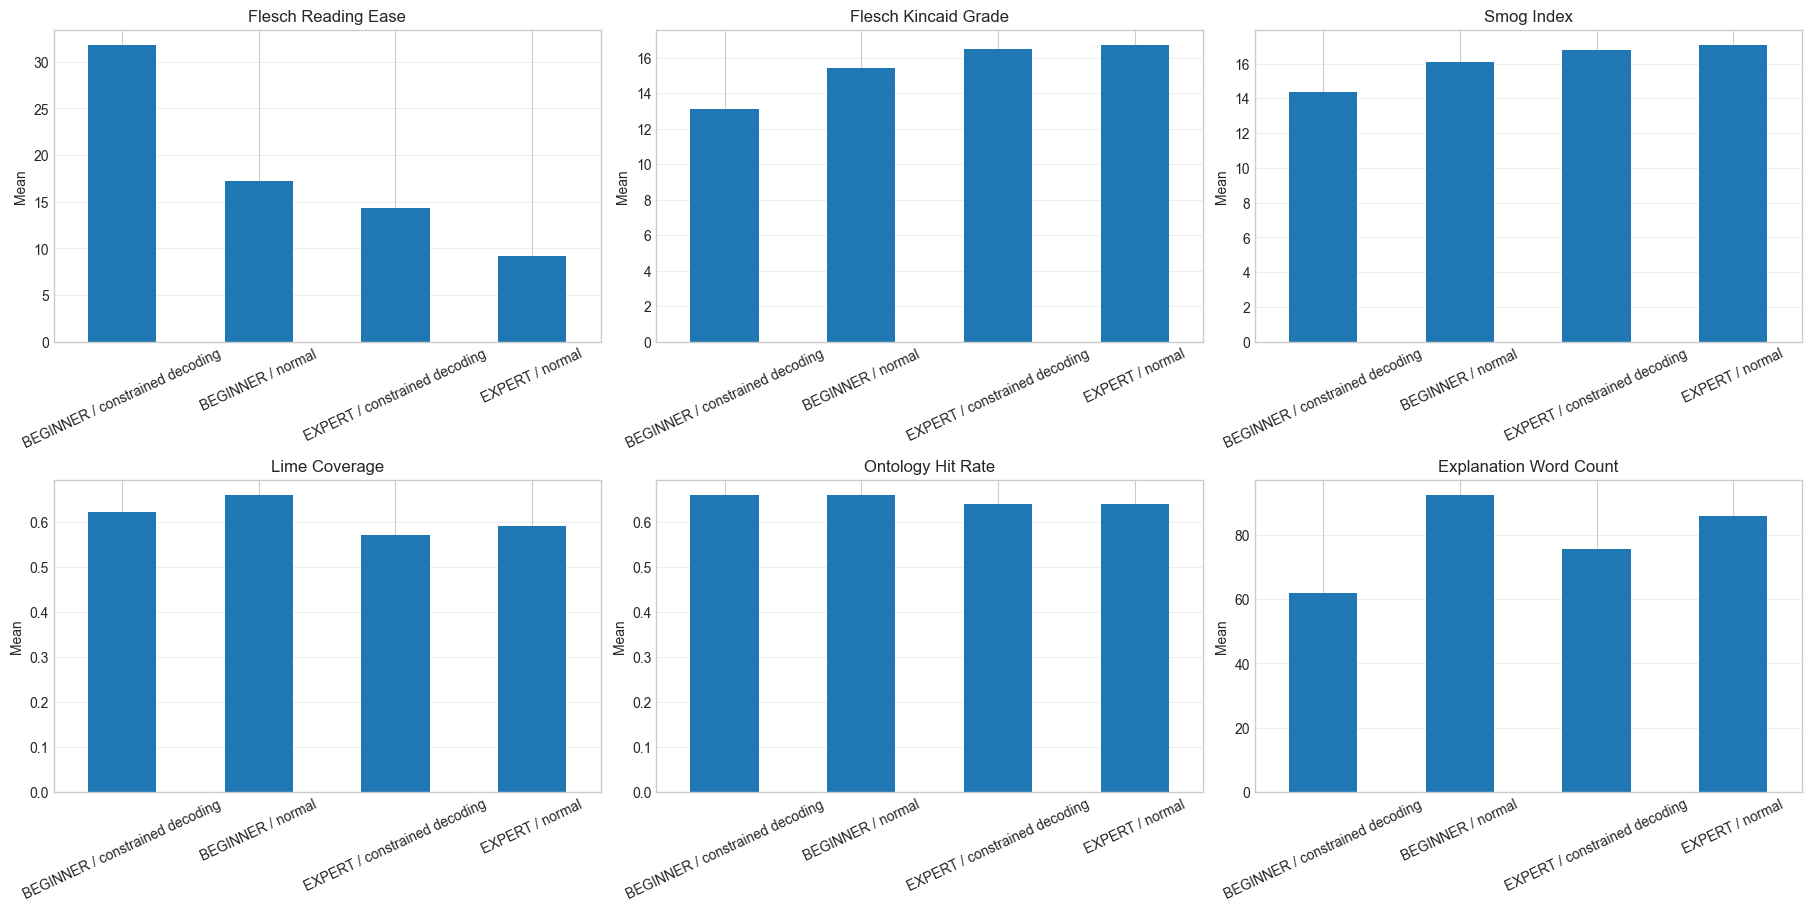

In [5]:
summary_by_file = (
    df.groupby("experiment")[metric_cols + ["explanation_word_count", "in_target_bracket"]]
    .mean()
    .round(3)
)
summary_by_file = summary_by_file.rename(columns={"in_target_bracket": "pct_in_bracket"})
summary_by_file["pct_in_bracket"] = (summary_by_file["pct_in_bracket"] * 100).round(1)
display(summary_by_file)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
plot_metrics = metric_cols + ["explanation_word_count"]
for ax, metric in zip(axes.ravel(), plot_metrics):
    summary_by_file[metric].plot(kind="bar", ax=ax, color="#1f77b4")
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Mean")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, axis="y", alpha=0.3)
plt.show()

## 4. Beginner vs expert comparison within each decoding mode

In [8]:
mode_summary = (
    df.groupby(["generation_mode", "user_category"])[metric_cols + ["explanation_word_count"]]
    .mean()
    .round(3)
)
display(mode_summary)

flesch_reading_ease  flesch_kincaid_grade  \
generation_mode user_category                                              
normal          BEGINNER                    25.666                14.093   
                EXPERT                      11.044                16.635   

                               smog_index  lime_coverage  ontology_hit_rate  \
generation_mode user_category                                                 
normal          BEGINNER           15.132          0.637               0.64   
                EXPERT             17.122          0.647               0.65   

                               explanation_word_count  
generation_mode user_category                          
normal          BEGINNER                        57.13  
                EXPERT                          68.00

## 5. Paired comparison: constrained decoding vs normal

In [5]:
def paired_comparison(audience: str) -> pd.DataFrame:
    normal = (
        df[(df["user_category"] == audience) & (df["generation_mode"] == "normal")]
        .sort_values("example_id")
        .reset_index(drop=True)
    )
    cd = (
        df[(df["user_category"] == audience) & (df["generation_mode"] == "constrained_decoding")]
        .sort_values("example_id")
        .reset_index(drop=True)
    )

    if len(normal) != len(cd):
        raise ValueError(
            f"{audience} has {len(normal)} normal rows and {len(cd)} constrained-decoding rows."
        )

    left_cols = ["example_id", "text", "predicted_class", "confidence", "explanation", "explanation_word_count"] + metric_cols
    merged = normal[left_cols].merge(
        cd[left_cols],
        on="example_id",
        suffixes=("_normal", "_cd"),
        how="inner",
    )

    for metric in metric_cols + ["confidence", "explanation_word_count"]:
        merged[f"{metric}_delta"] = merged[f"{metric}_cd"] - merged[f"{metric}_normal"]

    return merged

paired = {
    audience: paired_comparison(audience)
    for audience in sorted(df["user_category"].dropna().unique())
}

delta_summary = pd.DataFrame(
    {
        audience: table[[f"{metric}_delta" for metric in metric_cols + ["confidence", "explanation_word_count"]]].mean()
        for audience, table in paired.items()
    }
).T.round(3)
display(delta_summary)

for audience, table in paired.items():
    print(f"\n{audience} examples: top 5 largest readability improvements by constrained decoding")
    ranked = table.sort_values("flesch_reading_ease_delta", ascending=False)[
        [
            "example_id",
            "text_normal",
            "predicted_class_normal",
            "flesch_reading_ease_normal",
            "flesch_reading_ease_cd",
            "flesch_reading_ease_delta",
            "flesch_kincaid_grade_normal",
            "flesch_kincaid_grade_cd",
            "smog_index_normal",
            "smog_index_cd",
            "lime_coverage_normal",
            "lime_coverage_cd",
            "ontology_hit_rate_normal",
            "ontology_hit_rate_cd",
        ]
    ].head(5)
    display(ranked)

,flesch_reading_ease_delta,flesch_kincaid_grade_delta,smog_index_delta,lime_coverage_delta,ontology_hit_rate_delta,confidence_delta,explanation_word_count_delta
BEGINNER,1.696,-0.302,-0.277,-0.003,0.00,0.0,1.06
EXPERT,6.887,-0.908,-0.667,-0.027,-0.02,0.0,2.36



BEGINNER examples: top 5 largest readability improvements by constrained decoding


,example_id,text_normal,predicted_class_normal,flesch_reading_ease_normal,flesch_reading_ease_cd,flesch_reading_ease_delta,flesch_kincaid_grade_normal,flesch_kincaid_grade_cd,smog_index_normal,smog_index_cd,lime_coverage_normal,lime_coverage_cd,ontology_hit_rate_normal,ontology_hit_rate_cd
21,21,Effect of increased left atrial pressure on breathing frequency in anestheti...,Cardiovascular diseases,-11.430000,33.288810,44.718810,18.580000,14.412857,17.122413,14.554593,0.0,1.0,0.0,1.0
14,14,The role of elective lymph node dissection in the management of patients wit...,Neoplasms,17.382143,54.406667,37.024524,14.312857,10.461799,14.554593,13.707051,0.0,1.0,0.0,1.0
39,39,Circadian variations in myocardial ischemia. Implications for management. Ex...,Cardiovascular diseases,-11.430000,25.576496,37.006496,18.580000,14.101514,17.122413,14.906228,0.0,1.0,0.0,1.0
12,12,Patient age and results of balloon aortic valvuloplasty: the Mansfield Scien...,Cardiovascular diseases,16.129130,52.653696,36.524566,16.723478,9.840354,17.693802,11.602472,1.0,1.0,1.0,1.0
2,2,Endometriosis associated with massive ascites and absence of pelvic peritone...,Digestive system diseases,11.741916,40.619423,28.877507,21.186039,12.438077,20.267339,13.023867,1.0,1.0,1.0,1.0



EXPERT examples: top 5 largest readability improvements by constrained decoding


,example_id,text_normal,predicted_class_normal,flesch_reading_ease_normal,flesch_reading_ease_cd,flesch_reading_ease_delta,flesch_kincaid_grade_normal,flesch_kincaid_grade_cd,smog_index_normal,smog_index_cd,lime_coverage_normal,lime_coverage_cd,ontology_hit_rate_normal,ontology_hit_rate_cd
4,4,Salvage chemotherapy for patients with germ cell tumors. The Memorial Sloan-...,Neoplasms,12.496642,38.386842,25.890201,16.671175,12.625263,18.243606,15.579742,1.0,1.0,1.0,1.0
0,0,Normalization of ventilation/perfusion relationships after liver transplanta...,Digestive system diseases,5.532500,31.371604,25.839104,16.462500,13.901861,17.122413,15.112258,0.0,1.0,0.0,1.0
13,13,How ancient is temporal arteritis? Realism is one of the characteristics of ...,Cardiovascular diseases,6.652727,31.807083,25.154355,17.796818,14.238606,17.971250,15.381576,1.0,1.0,1.0,1.0
45,45,Neuro-ophthalmic manifestations of human immunodeficiency virus infection. B...,Neoplasms,17.116569,41.504190,24.387621,16.502941,13.122060,16.322122,14.906228,1.0,1.0,1.0,1.0
27,27,Histochemical demonstration of 5'-nucleotidase activity in inflammatory musc...,General pathological conditions,-6.166379,18.102616,24.268994,20.143789,18.125105,20.503739,19.032713,1.0,1.0,1.0,1.0


In [ ]:
# ── Bracket conformance — the headline result ─────────────────────────────
bracket_summary = (
    df.groupby(["user_category", "generation_mode"])["in_target_bracket"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"in_target_bracket": "pct_in_bracket"})
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {
    ("BEGINNER", "normal"): "#aec6e8",
    ("BEGINNER", "constrained_decoding"): "#1f77b4",
    ("EXPERT", "normal"): "#f5c08a",
    ("EXPERT", "constrained_decoding"): "#dd8452",
}
x_positions = {"BEGINNER": 0, "EXPERT": 1}
bar_width = 0.35

for _, row in bracket_summary.iterrows():
    cat, mode, pct = row["user_category"], row["generation_mode"], row["pct_in_bracket"]
    offset = -bar_width / 2 if mode == "normal" else bar_width / 2
    x = x_positions[cat] + offset
    color = colors.get((cat, mode), "#888888")
    ax.bar(x, pct, width=bar_width, color=color, label=f"{cat} / {mode.replace('_', ' ')}")
    ax.text(x, pct + 1, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(list(x_positions.keys()))
ax.set_ylabel("% Explanations Within Target Readability Bracket")
ax.set_title("Bracket Conformance: Normal vs Constrained Decoding")
ax.set_ylim(0, 110)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8)

plt.tight_layout()
plt.savefig("outputs/bracket_conformance.png", dpi=150)
plt.show()
print("[✓] Saved outputs/bracket_conformance.png")

## 6. Save combined comparison tables

In [6]:
COMPARATIVE_RESULTS_PATH = Path("outputs/comparative_analysis.csv")
SUMMARY_PATH = Path("outputs/comparative_summary.csv")
DELTA_PATH = Path("outputs/comparative_deltas.csv")

df.to_csv(COMPARATIVE_RESULTS_PATH, index=False)
summary_by_file.to_csv(SUMMARY_PATH)
delta_summary.to_csv(DELTA_PATH)

print(f"Saved combined rows to {COMPARATIVE_RESULTS_PATH}")
print(f"Saved summary table to {SUMMARY_PATH}")
print(f"Saved paired deltas to {DELTA_PATH}")

Saved combined rows to outputs\comparative_analysis.csv
Saved summary table to outputs\comparative_summary.csv
Saved paired deltas to outputs\comparative_deltas.csv
